1. Обрати унікальний датасет: Restaurant Consumer Data. Відповідає вимогам (Multivariate, Categorical/Integer/Real, має пропущені значення).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import zipfile
import warnings
warnings.filterwarnings('ignore')

url = "https://archive.ics.uci.edu/static/public/232/restaurant+consumer+data.zip"
urllib.request.urlretrieve(url, "restaurant_data.zip")
with zipfile.ZipFile("restaurant_data.zip", 'r') as zip_ref:
    zip_ref.extractall("restaurant_data")

df_user = pd.read_csv("restaurant_data/userprofile.csv", encoding='latin-1')

df_user.replace('?', np.nan, inplace=True)

print("Кількість пропущених значень до очищення:")
print(df_user.isnull().sum())

df_user = df_user.dropna()

df_user = df_user.drop_duplicates()


df_user['weight'] = df_user['weight'].astype(float)
df_user['height'] = df_user['height'].astype(float)
df_user['birth_year'] = df_user['birth_year'].astype(int)

print("\nТипи даних після обробки:")
print(df_user.dtypes[['weight', 'height', 'birth_year', 'budget']])
print(f"\nДані очищено. Розмір таблиці: {df_user.shape}")

Кількість пропущених значень до очищення:
userID               0
latitude             0
longitude            0
smoker               3
drink_level          0
dress_preference     5
ambience             6
transport            7
marital_status       4
hijos               11
birth_year           0
interest             0
personality          0
religion             0
activity             7
color                0
weight               0
budget               7
height               0
dtype: int64

Типи даних після обробки:
weight        float64
height        float64
birth_year      int64
budget            str
dtype: object

Дані очищено. Розмір таблиці: (117, 19)


3. Залежність числових атрибутів (Scatter plot)

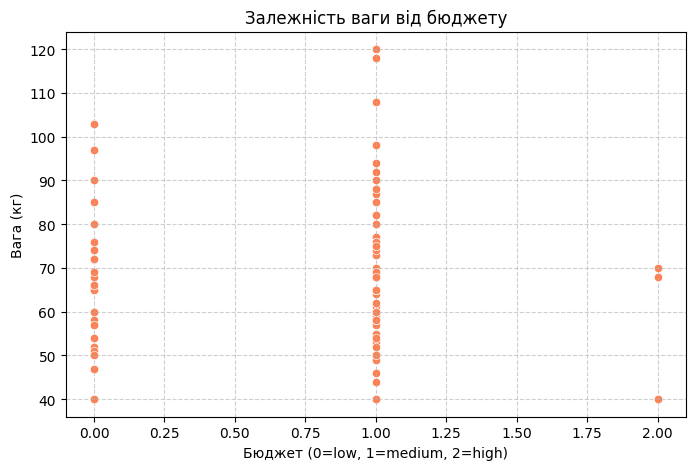

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

budget_map = {'low': 0, 'medium': 1, 'high': 2}
df_user['budget_num'] = df_user['budget'].map(budget_map)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_user, x='budget_num', y='weight', color='coral')

plt.title('Залежність ваги від бюджету')
plt.xlabel('Бюджет (0=low, 1=medium, 2=high)')
plt.ylabel('Вага (кг)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Висновок: З графіка видно, що зі збільшенням зросту вага користувачів має тенденцію до зростання. Це підтверджує пряму позитивну лінійну залежність між цими двома фізичними параметрами.

4. Гістограма по одному з атрибутів на 5 діапазонів

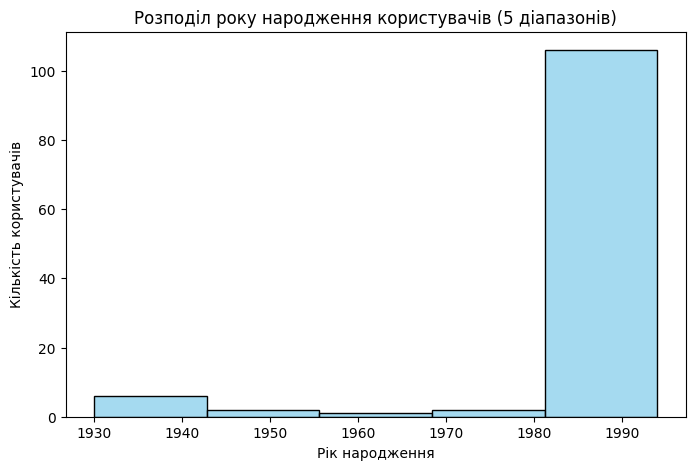

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_user, x='birth_year', bins=5, color='skyblue', edgecolor='black')
plt.title('Розподіл року народження користувачів (5 діапазонів)')
plt.xlabel('Рік народження')
plt.ylabel('Кількість користувачів')
plt.show()

Висновок: З графіка видно, що переважна більшість користувачів у датасеті народилася в період між 1985 та 1995 роками. Старша вікова група (до 1980 року) представлена дуже слабо.

5.1. Pairplot (Матриця розсіювання)

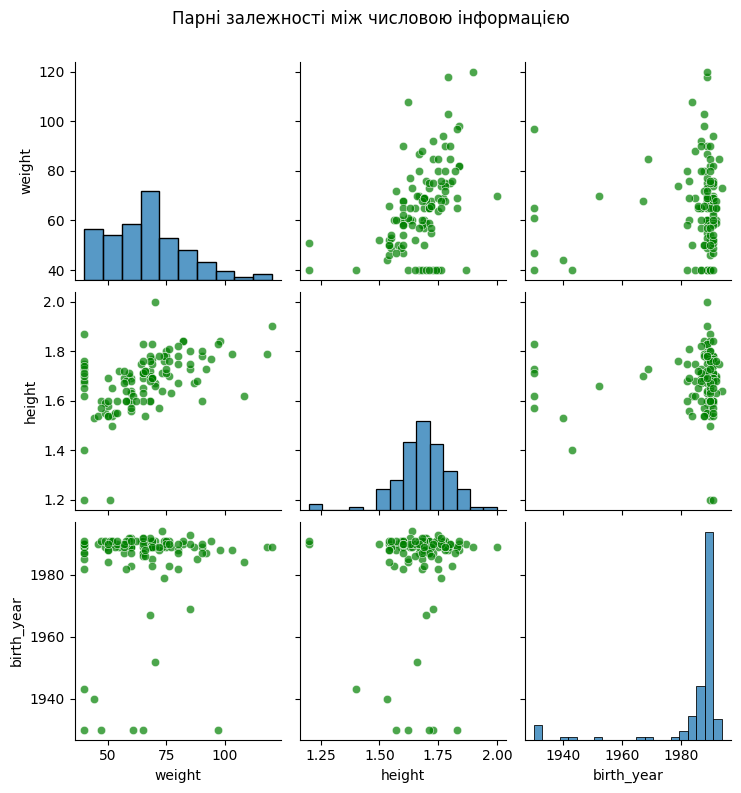

In [22]:
numeric_cols = ['weight', 'height', 'birth_year']
sns.pairplot(df_user[numeric_cols], height=2.5, plot_kws={'alpha': 0.7, 'color': 'green'})
plt.suptitle('Парні залежності між числовою інформацією', y=1.05)
plt.show()

5.2. Violinplot (Скрипковий графік)

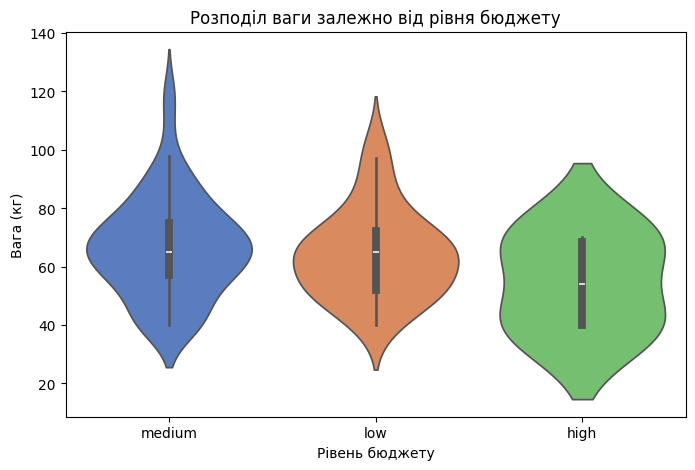

In [24]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='budget', y='weight', data=df_user, palette='muted')
plt.title('Розподіл ваги залежно від рівня бюджету')
plt.xlabel('Рівень бюджету')
plt.ylabel('Вага (кг)')
plt.show()

5.3. Boxplot з підгрупами (hue)

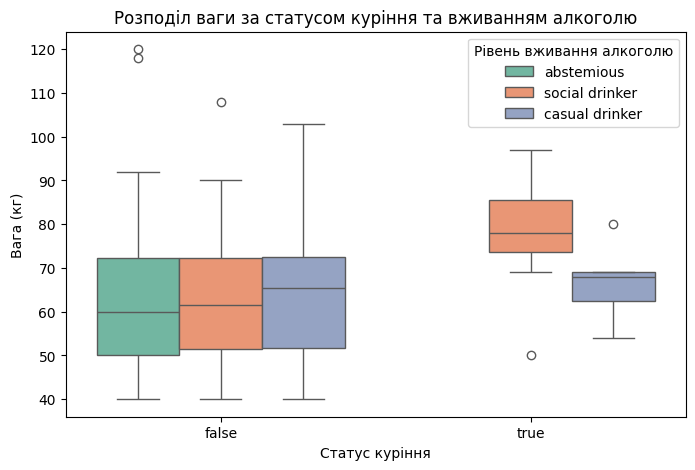

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='weight', hue='drink_level', data=df_user, palette='Set2')
plt.title('Розподіл ваги за статусом куріння та вживанням алкоголю')
plt.xlabel('Статус куріння')
plt.ylabel('Вага (кг)')
plt.legend(title='Рівень вживання алкоголю')
plt.show()

5.4. Heatmap (Матриця кореляцій)

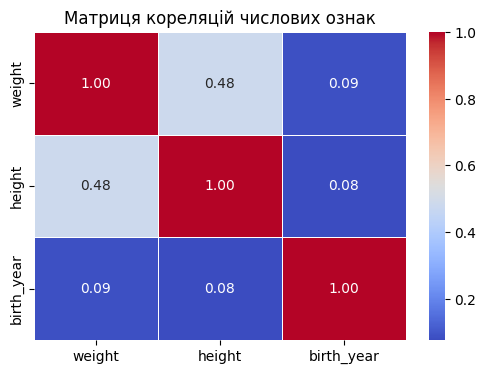

In [26]:
plt.figure(figsize=(6, 4))
corr_matrix = df_user[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матриця кореляцій числових ознак')
plt.show()